In [217]:
import xarray as xr
import pandas as pd


ds = xr.open_dataset("single-point-timeseries_sel_vars_1940-today.nc")


print(ds)


df = ds.to_dataframe().reset_index()


print(df.columns)


print(df.head())

<xarray.Dataset> Size: 27MB
Dimensions:     (valid_time: 757296)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2026-05-22T23:...
    latitude    float64 8B ...
    longitude   float64 8B ...
Data variables:
    u10         (valid_time) float32 3MB ...
    v10         (valid_time) float32 3MB ...
    t2m         (valid_time) float32 3MB ...
    sp          (valid_time) float32 3MB ...
    ssrd        (valid_time) float32 3MB ...
    tcc         (valid_time) float32 3MB ...
    tp          (valid_time) float32 3MB ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts
Index(['valid_time', 'u10', 'v10', 't2m', 'sp', 'ssrd', 'tcc', 

In [218]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 757296 entries, 0 to 757295
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   valid_time  757296 non-null  datetime64[ns]
 1   u10         757296 non-null  float32       
 2   v10         757296 non-null  float32       
 3   t2m         757296 non-null  float32       
 4   sp          757296 non-null  float32       
 5   ssrd        757272 non-null  float32       
 6   tcc         757296 non-null  float32       
 7   tp          757272 non-null  float32       
 8   latitude    757296 non-null  float64       
 9   longitude   757296 non-null  float64       
dtypes: datetime64[ns](1), float32(7), float64(2)
memory usage: 37.6 MB
None


In [219]:
# NaN
print(df.isna().sum())

valid_time     0
u10            0
v10            0
t2m            0
sp             0
ssrd          24
tcc            0
tp            24
latitude       0
longitude      0
dtype: int64


In [220]:
print(df["valid_time"].duplicated().sum())

0


In [221]:
print(df["valid_time"].diff().value_counts())

valid_time
0 days 01:00:00    757295
Name: count, dtype: int64


# Initial XGBoost Baseline

A first XGBoost regression model was trained using lag features and rolling statistics in order to predict precipitation at 17:00 each day.

The model was initially evaluated using a simple chronological train-test split.

In [222]:
df = df.drop(columns=["latitude", "longitude"])


In [223]:
df["hour"] = df["valid_time"].dt.hour
df["dayofyear"] = df["valid_time"].dt.dayofyear
df["month"] = df["valid_time"].dt.month

In [224]:
lags = [1, 3, 6, 12, 24, 48, 72]

# Variables used as predictors
# tp is excluded because it is the target variable
vars_to_lag = ["t2m", "sp", "tcc", "u10", "v10", "tp"]

#lags = [1, 3, 6, 12, 24, 48, 72]



for var in vars_to_lag:
    for lag in lags:
        df[f"{var}_lag{lag}"] = df[var].shift(lag)

In [225]:

df["tcc_roll24_mean"] = df["tcc"].rolling(24).mean()
df["sp_roll24_mean"] = df["sp"].rolling(24).mean()
df["t2m_roll24_mean"] = df["t2m"].rolling(24).mean()
df["u10_roll24_mean"] = df["u10"].rolling(24).mean()
df["v10_roll24_mean"] = df["v10"].rolling(24).mean()
df["tp_roll24_mean"] = df["tp"].rolling(24).mean()
#df = df.dropna().copy()

In [226]:
# Target: precipitation 24 time steps ahead
df["tp_target"] = df["tp"].shift(-1)

# Drop NaNs from lags, rolling means, and future target
df = df.dropna().copy()

# Features
X = df.drop(columns=["valid_time", "tp_target"], errors="ignore")

# Extra safety: remove any accidental tp-derived feature
X = X[[col for col in X.columns if not col.startswith("tp_target")]]

# Target
y = df["tp_target"]

In [227]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

time_train = df["valid_time"].iloc[:train_end]
time_val = df["valid_time"].iloc[train_end:val_end]
time_test = df["valid_time"].iloc[val_end:]

In [228]:
print("Train:", time_train.min(), "to", time_train.max(), X_train.shape)
print("Validation:", time_val.min(), "to", time_val.max(), X_val.shape)
print("Test:", time_test.min(), "to", time_test.max(), X_test.shape)

Train: 1940-01-05 00:00:00 to 2000-06-22 22:00:00 (530039, 58)
Validation: 2000-06-22 23:00:00 to 2013-06-07 10:00:00 (113580, 58)
Test: 2013-06-07 11:00:00 to 2026-05-22 22:00:00 (113580, 58)


In [229]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [230]:
pred = model.predict(X_test)
mask_17_test = time_test.dt.hour == 17

y_test_17 = y_test[mask_17_test]
pred_17 = pred[mask_17_test]

In [231]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test_17, pred_17)
rmse = np.sqrt(mean_squared_error(y_test_17, pred_17))
corr = np.corrcoef(y_test_17, pred_17)[0,1]

print("Test metrics at 17:00")
print("MAE:", mae)
print("RMSE:", rmse)
print("Correlation:", corr)

Test metrics at 17:00
MAE: 4.980171433999203e-05
RMSE: 0.0001899422067033072
Correlation: 0.7671121923714426


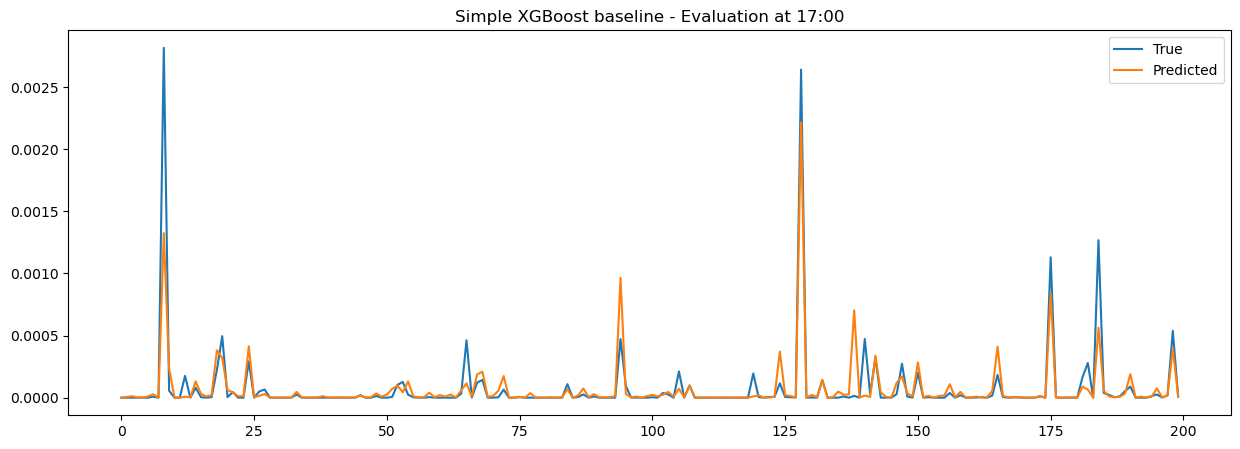

In [232]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(15,5))

plt.plot(y_test_17.values[:200], label="True")
plt.plot(pred_17[:200], label="Predicted")

plt.title("Simple XGBoost baseline - Evaluation at 17:00")
plt.legend()
plt.show()

In [233]:
print(y_test_17.head(10))
print(y_test_17.index[:10])
print(y_test_17.shape)
print(y_test_17.describe())

643721    0.000000
643745    0.000000
643769    0.000000
643793    0.000000
643817    0.000000
643841    0.000000
643865    0.000008
643889    0.000000
643913    0.002818
643937    0.000056
Name: tp_target, dtype: float32
Index([643721, 643745, 643769, 643793, 643817, 643841, 643865, 643889, 643913,
       643937],
      dtype='int64')
(4733,)
count    4733.000000
mean        0.000073
std         0.000292
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000012
max         0.009419
Name: tp_target, dtype: float64


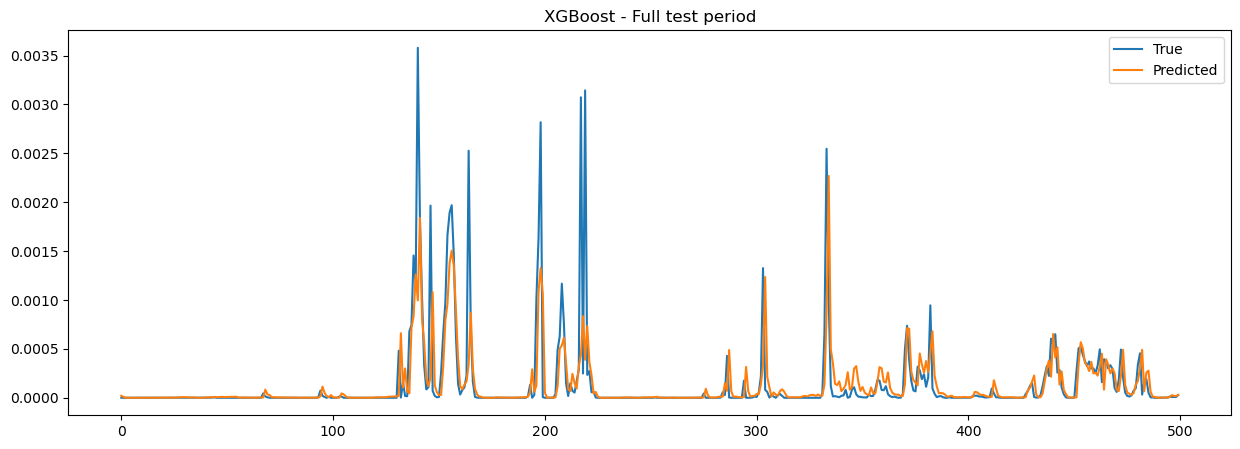

In [234]:
pred = model.predict(X_test)

plt.figure(figsize=(15,5))

plt.plot(y_test.values[:500], label="True")
plt.plot(pred[:500], label="Predicted")

plt.title("XGBoost - Full test period")
plt.legend()
plt.show()

# Improved Validation Strategy

The dataset was further divided into chronological training, validation, and test sets in order to perform more reliable model evaluation and hyperparameter tuning while avoiding temporal leakage.

In [235]:
"""
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]
"""

'\nn = len(df)\n\ntrain_end = int(n * 0.70)\nval_end = int(n * 0.85)\n\nX_train = X.iloc[:train_end]\ny_train = y.iloc[:train_end]\n\nX_val = X.iloc[train_end:val_end]\ny_val = y.iloc[train_end:val_end]\n\nX_test = X.iloc[val_end:]\ny_test = y.iloc[val_end:]\n'

In [236]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

pred_val = model.predict(X_val)

In [237]:
weights_train = np.where(y_train > 0, 5, 1)

In [238]:
model_w = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_w.fit(
    X_train,
    y_train,
    sample_weight=weights_train
)

pred_val_w = model_w.predict(X_val)

In [239]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    
    print(name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("Correlation:", corr)

evaluate(y_val, pred_val, "Baseline XGBoost")
evaluate(y_val, pred_val_w, "Weighted XGBoost")

Baseline XGBoost
MAE: 5.397295535658486e-05
RMSE: 0.00019487370121694196
Correlation: 0.7712448905478544
Weighted XGBoost
MAE: 5.734438673243858e-05
RMSE: 0.00019471403380903968
Correlation: 0.7709429411409751


Weighted XGBoost @ 17:00
MAE: 5.626139318337664e-05
RMSE: 0.00017412030765715354
Correlation: 0.7686982424398119


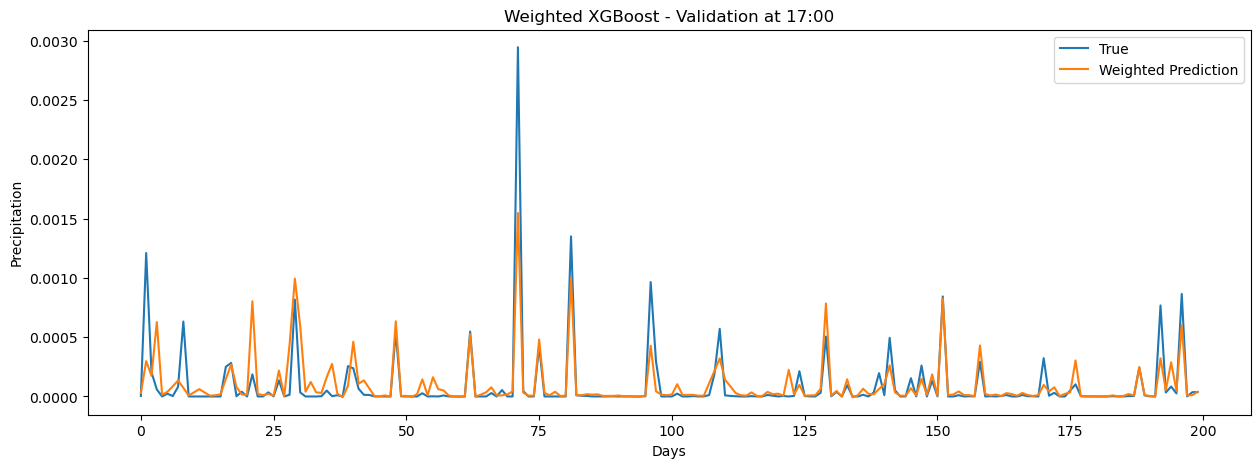

In [240]:
mask_17_val = time_val.dt.hour == 17
y_val_17 = y_val[mask_17_val]
pred_val_w_17 = pred_val_w[mask_17_val.values]

evaluate(y_val_17, pred_val_w_17, "Weighted XGBoost @ 17:00")

plt.figure(figsize=(15,5))
plt.plot(y_val_17.values[:200], label="True")
plt.plot(pred_val_w_17[:200], label="Weighted Prediction")
plt.xlabel("Days")
plt.ylabel("Precipitation")
plt.title("Weighted XGBoost - Validation at 17:00")
plt.legend()
plt.show()

In [241]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
#from xgboost import XGBRegressor

param_dist = {
    "n_estimators": [200, 300, 500, 800],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 8],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "gamma": [0, 0.1, 0.3, 1]
}
tscv = TimeSeriesSplit(n_splits=3)
xgb = XGBRegressor(
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(
    X_train,
    y_train,
    sample_weight=weights_train
)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamm...
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0, 0.1, 0.3, 1],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6, 8],
                                        'min_child_weight': [1, 3, 5, 10],
                                        'n_estimators': [200, 300, 500, 800],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [242]:
print(random_search.best_params_)

{'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.6}


In [243]:
best_model = random_search.best_estimator_

pred_val_best = best_model.predict(X_val)

In [244]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    corr = np.corrcoef(y_true, y_pred)[0, 1]

    print(name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("Correlation:", corr)

mask_17_val = time_val.dt.hour == 17

evaluate_model(y_val[mask_17_val], pred_val[mask_17_val.values],      "Baseline XGBoost @ 17:00")
evaluate_model(y_val[mask_17_val], pred_val_w[mask_17_val.values],    "Weighted XGBoost @ 17:00")
evaluate_model(y_val[mask_17_val], pred_val_best[mask_17_val.values], "Tuned Weighted XGBoost @ 17:00")

Baseline XGBoost @ 17:00
MAE: 5.288864849717356e-05
RMSE: 0.00017734655667219637
Correlation: 0.7584718278743684
Weighted XGBoost @ 17:00
MAE: 5.626139318337664e-05
RMSE: 0.00017412030765715354
Correlation: 0.7686982424398119
Tuned Weighted XGBoost @ 17:00
MAE: 5.627520658890717e-05
RMSE: 0.00017280420678342793
Correlation: 0.7729226472913951


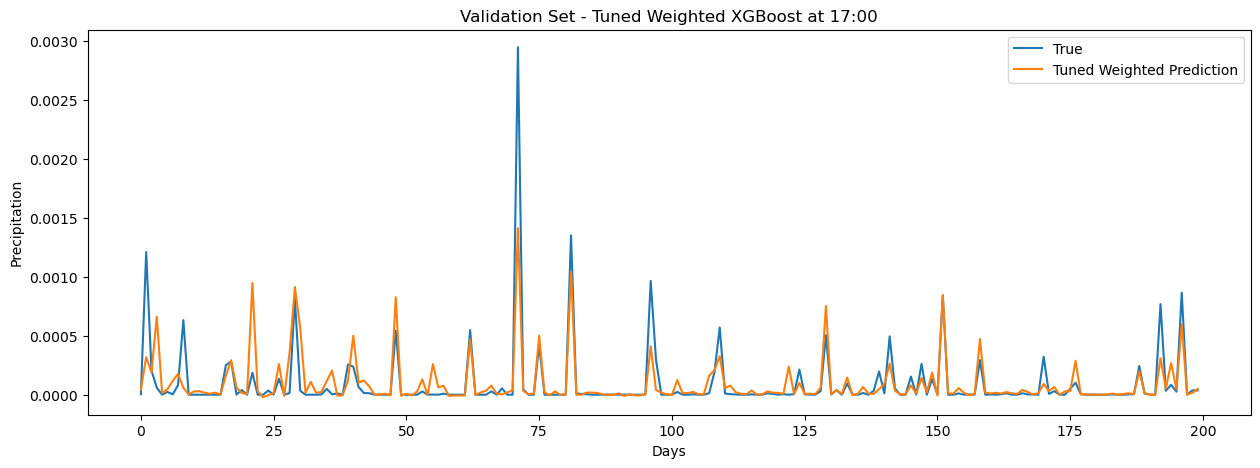

In [245]:
mask_17_val = time_val.dt.hour == 17

plt.figure(figsize=(15,5))
plt.plot(y_val[mask_17_val].values[:200], label="True")
plt.plot(pred_val_best[mask_17_val.values][:200], label="Tuned Weighted Prediction")

plt.xlabel("Days")
plt.ylabel("Precipitation")
plt.title("Validation Set - Tuned Weighted XGBoost at 17:00")
plt.legend()
plt.show()

# Log-Transformed and Weighted XGBoost Regression

The precipitation target variable is highly imbalanced, with many near-zero values and relatively few intense rainfall events. This often leads to underestimation of large precipitation peaks in standard regression models.

To address this issue, a logarithmic transformation was applied to the target variable using:

y = log(1 + tp)

This transformation compresses extreme precipitation values and produces a more stable target distribution for regression.

In addition, sample weighting was introduced during training in order to increase the importance of rainfall events, particularly heavier precipitation cases, which are underrepresented in the dataset.

The tuned XGBoost model was then retrained using:
- logarithmically transformed precipitation targets,
- weighted samples,
- and the previously optimized hyperparameters.

In [246]:
import numpy as np

y = np.log1p(df["tp_target"])

In [247]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]
time_train = df["valid_time"].iloc[:train_end]
time_val   = df["valid_time"].iloc[train_end:val_end]
time_test  = df["valid_time"].iloc[val_end:]


In [248]:
weights_train = 1 + 5000 * np.expm1(y_train)

In [249]:
from xgboost import XGBRegressor

model_log = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_log.fit(
    X_train,
    y_train,
    sample_weight=weights_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [250]:
pred_log = model_log.predict(X_val)

In [251]:
pred_tp = np.expm1(pred_log)

y_val_tp = np.expm1(y_val)

In [252]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mask_17_val = time_val.dt.hour == 17

mae = mean_absolute_error(y_val_tp[mask_17_val], pred_tp[mask_17_val.values])
rmse = np.sqrt(mean_squared_error(y_val_tp[mask_17_val], pred_tp[mask_17_val.values]))
corr = np.corrcoef(y_val_tp[mask_17_val], pred_tp[mask_17_val.values])[0,1]

print("MAE:", mae)
print("RMSE:", rmse)
print("Correlation:", corr)

# Γενική αξιολόγηση
evaluate_model(y_val_tp, pred_val, "Model - ALL hours")



MAE: 7.994816405698657e-05
RMSE: 0.0002035438140847561
Correlation: 0.7316324007398464
Model - ALL hours
MAE: 5.397295535658486e-05
RMSE: 0.00019487371033236793
Correlation: 0.7712448899776669


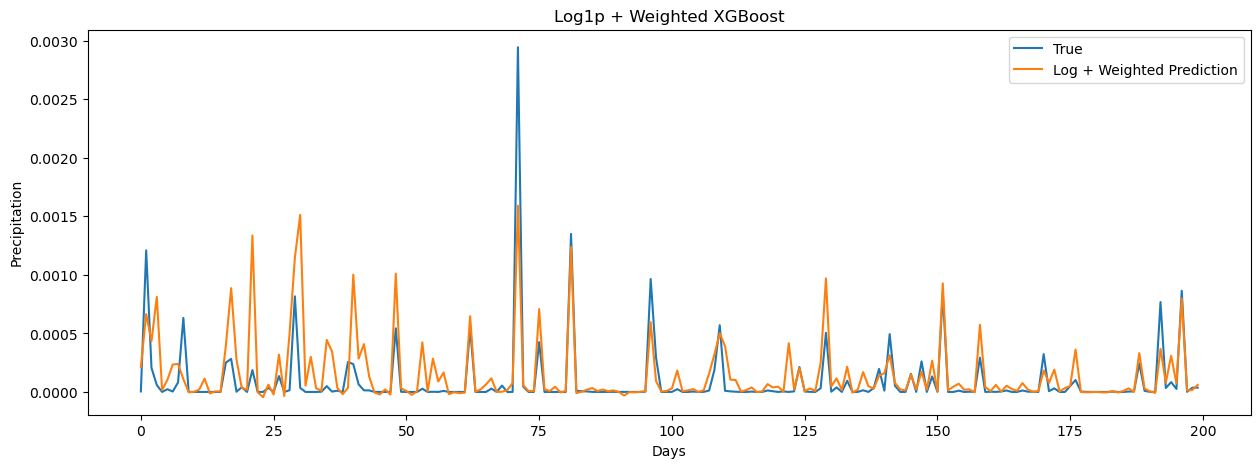

In [253]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))


plt.plot(y_val_tp[mask_17_val].values[:200], label="True")
plt.plot(pred_tp[mask_17_val.values][:200], label="Log + Weighted Prediction")
plt.xlabel("Days")
plt.ylabel("Precipitation")
plt.title("Log1p + Weighted XGBoost")

plt.legend()
plt.show()

In [254]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

mask_17_val = time_val.dt.hour == 17

result = permutation_importance(
    model_log,
    X_val[mask_17_val],
    y_val[mask_17_val],  
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values("importance_mean", ascending=False)

importance_df.head(20)

,feature,importance_mean,importance_std
6,tp,0.000158,4.020956e-06
3,sp,0.000050,4.407046e-06
45,tp_lag1,0.000026,2.043243e-06
18,sp_lag3,0.000024,1.483378e-06
2,t2m,0.000022,2.239156e-06
19,sp_lag6,0.000022,9.801226e-07
1,v10,0.000018,1.368835e-06
4,ssrd,0.000014,2.053286e-06
15,t2m_lag48,0.000013,8.626322e-07
17,sp_lag1,0.000012,1.171581e-06


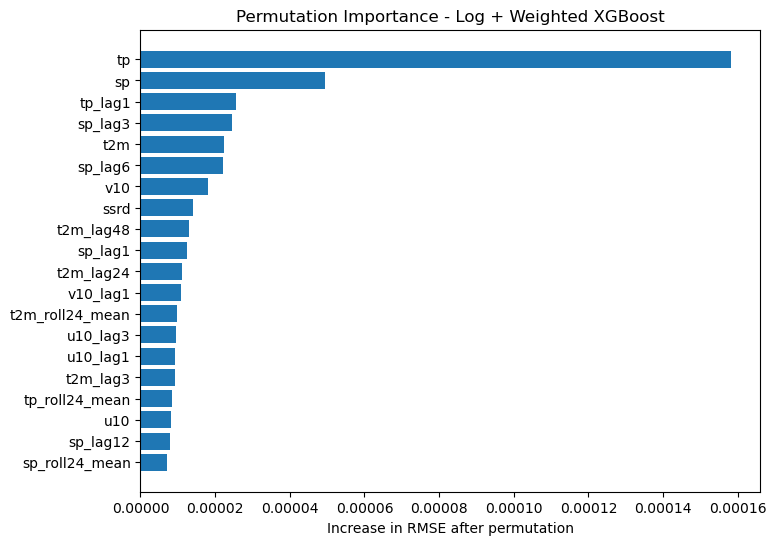

In [255]:
top_n = 20

plt.figure(figsize=(8, 6))

plt.barh(
    importance_df["feature"].head(top_n)[::-1],
    importance_df["importance_mean"].head(top_n)[::-1]
)

plt.xlabel("Increase in RMSE after permutation")
plt.title("Permutation Importance - Log + Weighted XGBoost")
plt.show()

Log + Weighted XGBoost @ 17:00 - TEST
MAE: 7.761782762827352e-05
RMSE: 0.00021184051740503096
Correlation: 0.7214550332181925


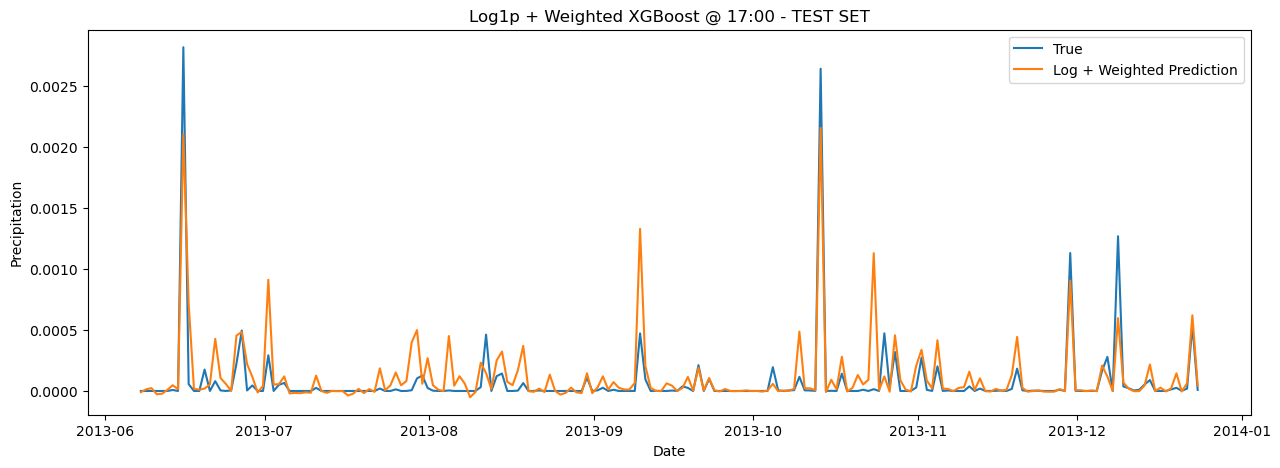

In [256]:
pred_log_test = model_log.predict(X_test)
pred_tp_test = np.expm1(pred_log_test)
y_test_tp = np.expm1(y_test)

mask_17_test = time_test.dt.hour == 17

evaluate_model(y_test_tp[mask_17_test], pred_tp_test[mask_17_test.values], "Log + Weighted XGBoost @ 17:00 - TEST")

time_test_17 = time_test[mask_17_test]

plt.figure(figsize=(15,5))
plt.plot(time_test_17.values[:200], y_test_tp[mask_17_test].values[:200], label="True")
plt.plot(time_test_17.values[:200], pred_tp_test[mask_17_test.values][:200], label="Log + Weighted Prediction")
plt.xlabel("Date")
plt.ylabel("Precipitation")
plt.title("Log1p + Weighted XGBoost @ 17:00 - TEST SET")
plt.legend()
plt.show()

In [257]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Same validation subset as permutation importance
mask_17_val = time_val.dt.hour == 17

X_val_17 = X_val[mask_17_val]
y_val_17 = y_val[mask_17_val]

# SHAP explainer for tree model
explainer = shap.TreeExplainer(model_log)

shap_values = explainer.shap_values(X_val_17)

# Mean absolute SHAP importance
shap_importance_df = pd.DataFrame({
    "feature": X_val_17.columns,
    "mean_abs_shap": abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

shap_importance_df.head(20)

,feature,mean_abs_shap
6,tp,0.000264
3,sp,0.000049
5,tcc,0.000034
2,t2m,0.000027
1,v10,0.000020
10,t2m_lag1,0.000018
18,sp_lag3,0.000018
4,ssrd,0.000018
45,tp_lag1,0.000017
0,u10,0.000016


<Figure size 800x600 with 0 Axes>

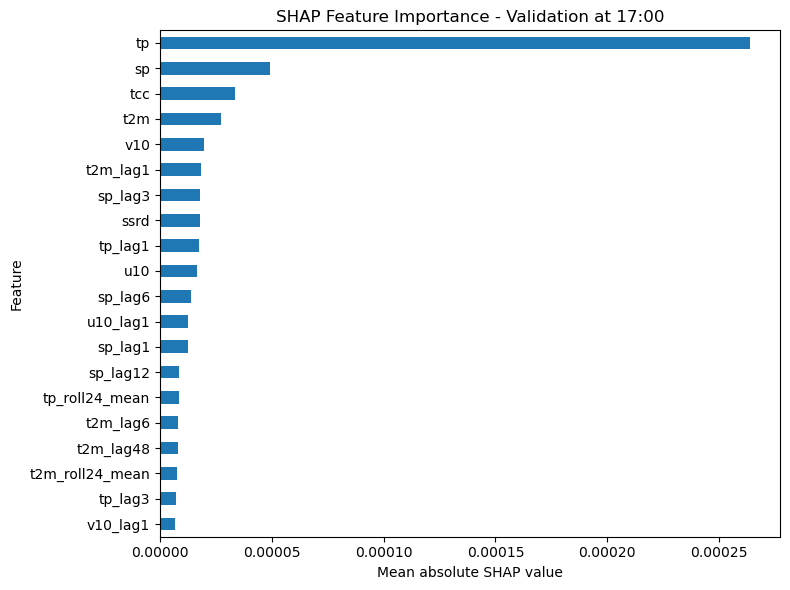

In [258]:
plt.figure(figsize=(8, 6))
shap_importance_df.head(20).sort_values("mean_abs_shap").plot(
    x="feature",
    y="mean_abs_shap",
    kind="barh",
    legend=False,
    figsize=(8, 6)
)

plt.title("SHAP Feature Importance - Validation at 17:00")
plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()